# Spaceship Titanic - 승객 이동 예측

## 개요
Kaggle Spaceship Titanic 대회 데이터를 활용하여 승객의 차원 이동 여부(Transported)를 예측하는 이진 분류 문제.  
8,693명의 승객 데이터를 분석하고, 시각화를 통해 핵심 패턴을 발견한 뒤,  
논리적 규칙 기반 전처리 → 피처 엔지니어링 → 다양한 모델 비교 → OOF Stacking 앙상블을 수행하여  
최종 **Public Score 0.809**를 달성하였다.

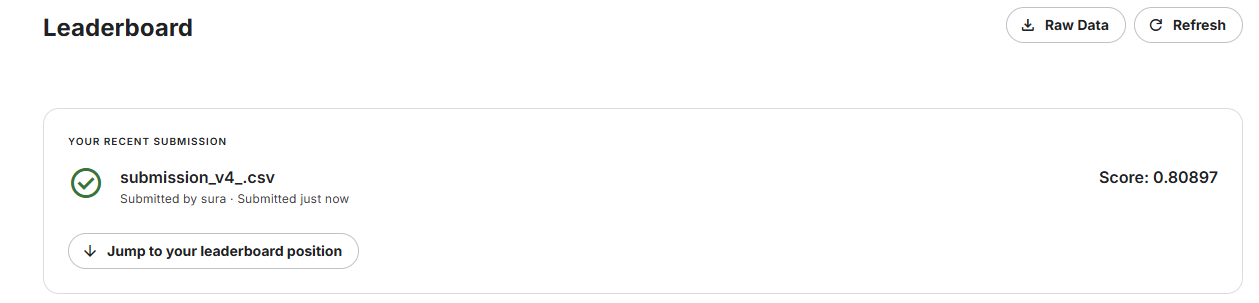



## 1. 데이터 로드 및 기본 탐색


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv(r'C:\Users\akals\Downloads\spaceship-titanic\train.csv')
test = pd.read_csv(r'C:\Users\akals\Downloads\spaceship-titanic\test.csv')

print(f"train: {train.shape}, test: {test.shape}")
print(f"\n=== 결측치 ===")
print(train.isnull().sum())
print(f"\n=== 타겟 분포 ===")
print(train['Transported'].value_counts())


train: (8693, 14), test: (4277, 13)

=== 결측치 ===
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

=== 타겟 분포 ===
Transported
True     4378
False    4315
Name: count, dtype: int64


**데이터 개요**: 14개 컬럼, 8,693행. 타겟(Transported)은 True/False가 거의 반반(50.4% / 49.6%).  
거의 모든 컬럼에 180~220개의 결측치가 존재하며, 이 결측치 처리가 핵심 과제임을 확인.


## 2. 데이터 시각화 및 탐색

타겟(Transported)과 각 변수의 관계를 시각화하여 핵심 패턴을 발견한다.


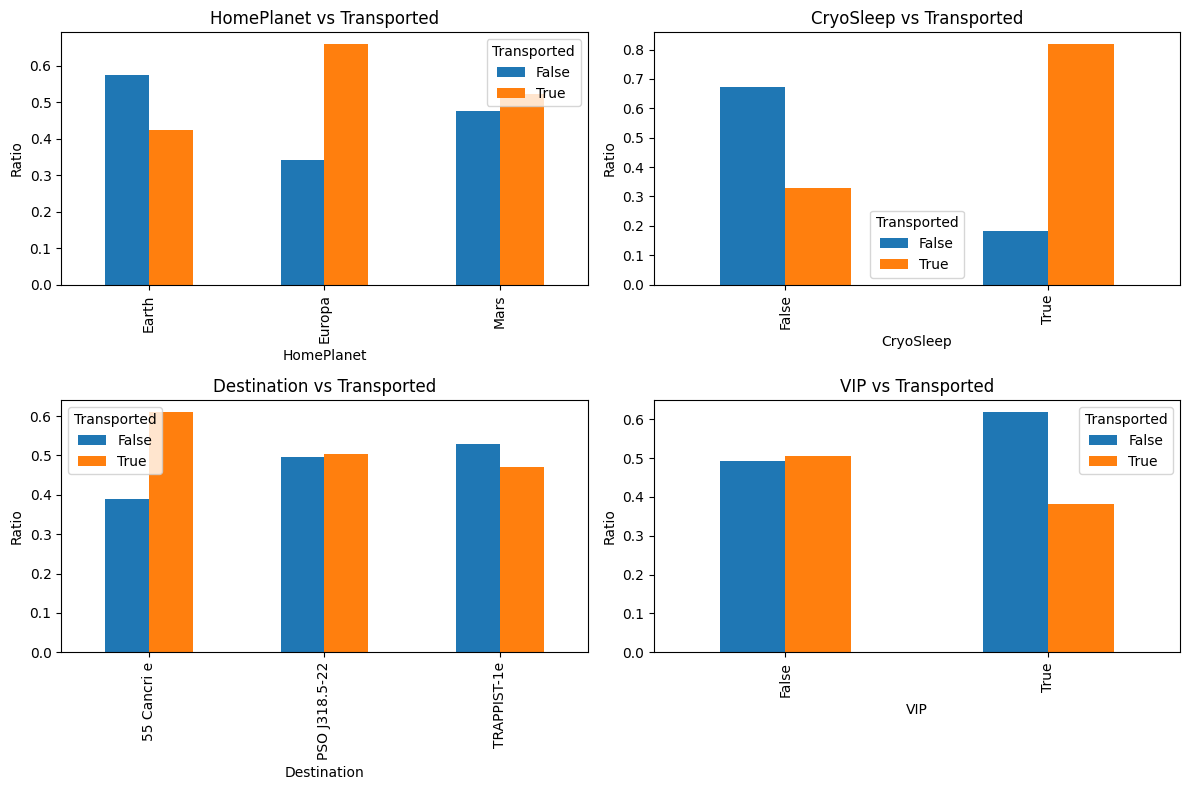

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']):
    pd.crosstab(train[col], train['Transported'], normalize='index').plot(kind='bar', ax=ax)
    ax.set_title(f'{col} vs Transported')
    ax.set_ylabel('Ratio')
plt.tight_layout()
plt.show()


### 카테고리 변수 인사이트
- **CryoSleep**(냉동수면) 상태인 승객은 이동될 확률이 높다 → 가장 강한 단일 예측 인자.
- **VIP** 승객은 오히려 이동 확률이 낮다.
- **Europa** 출신 승객이 다른 행성 대비 이동 확률이 높다.


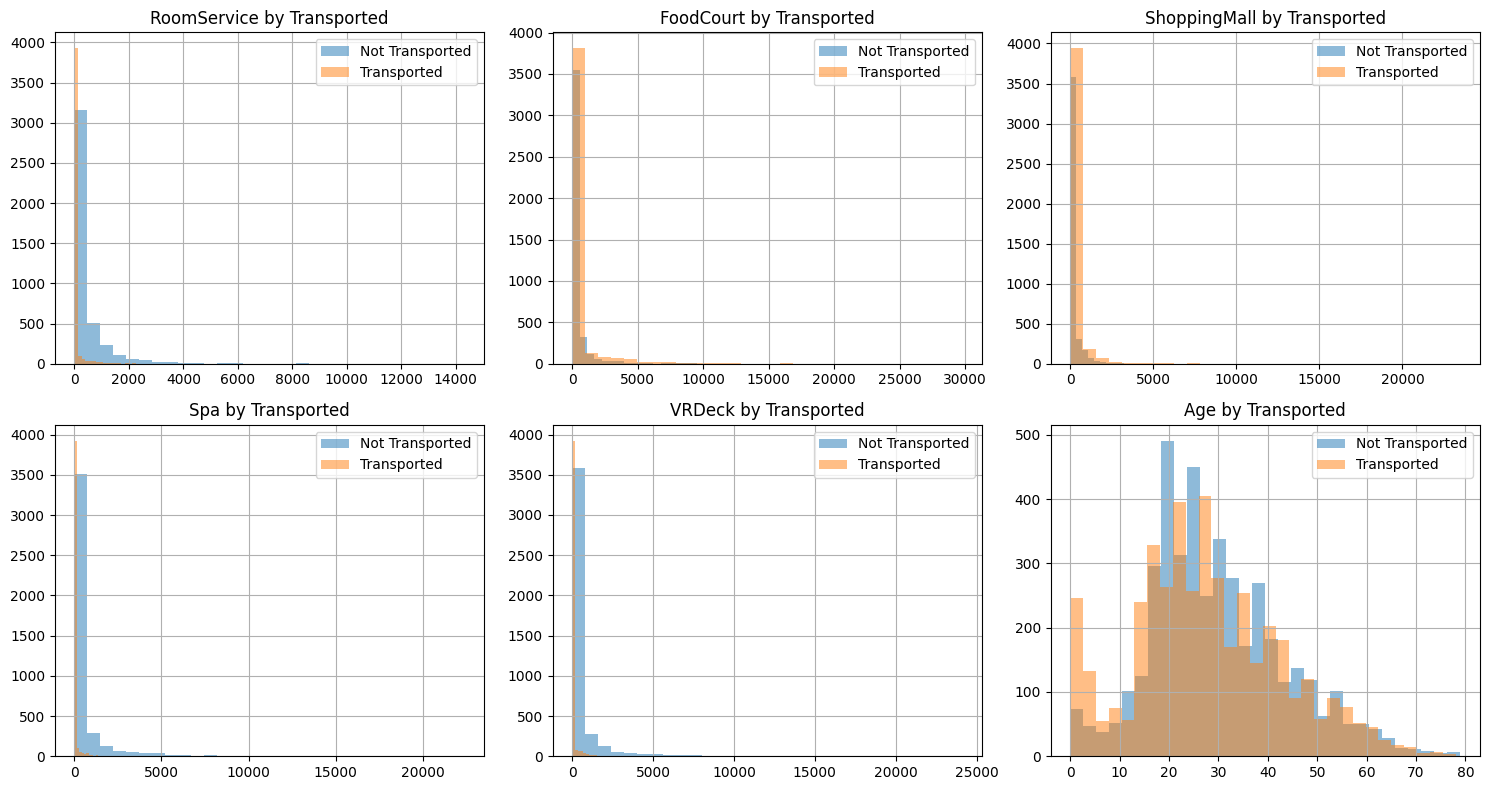

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Age']
for ax, col in zip(axes.flatten(), spend_cols):
    train.groupby('Transported')[col].hist(alpha=0.5, ax=ax, bins=30)
    ax.set_title(f'{col} by Transported')
    ax.legend(['Not Transported', 'Transported'])
plt.tight_layout()
plt.show()


### 수치형 변수 인사이트
- 지출 컬럼(RoomService, Spa, VRDeck 등)에서 **지출이 0인 승객이 이동 확률이 높다.**
- 이는 CryoSleep(냉동수면) 상태와 연관이 있다 — **냉동수면 중에는 지출이 불가능**하기 때문.
- 어린 승객(0~18세)이 이동될 확률이 상대적으로 높다.


In [7]:
# Cabin 분리 및 분석
train[['deck', 'cabin_num', 'side']] = train['Cabin'].str.split('/', expand=True)
print("=== deck vs Transported ===")
print(pd.crosstab(train['deck'], train['Transported'], normalize='index').round(3))
print("\n=== deck + side 조합별 Transported 비율 ===")
combo = train.groupby(['deck','side'])['Transported'].agg(['mean','count'])
print(combo.to_string())


=== deck vs Transported ===
Transported  False  True 
deck                     
A            0.504  0.496
B            0.266  0.734
C            0.320  0.680
D            0.567  0.433
E            0.643  0.357
F            0.560  0.440
G            0.484  0.516
T            0.800  0.200

=== deck + side 조합별 Transported 비율 ===
               mean  count
deck side                 
A    P     0.435897    117
     S     0.546763    139
B    P     0.674221    353
     S     0.784038    426
C    P     0.580645    341
     S     0.763547    406
D    P     0.403226    248
     S     0.465217    230
E    P     0.342657    429
     S     0.371365    447
F    P     0.410987   1438
     S     0.470501   1356
G    P     0.448276   1276
     S     0.583788   1283
T    P     0.250000      4
     S     0.000000      1


### Cabin 분석
- Cabin을 deck/num/side로 분리.
- **deck별 이동 확률에 큰 차이**: B(73%), C(68%) vs E(36%), D(43%).
- side(P/S)는 단독으로는 무관하나, **deck과 조합 시 S쪽이 일관적으로 높음** (예: B deck S 78% vs P 67%).
- 같은 Cabin의 승객이 **90.7%** 확률로 동일한 Transported 결과를 보임 → 가족 단위 패턴 존재.


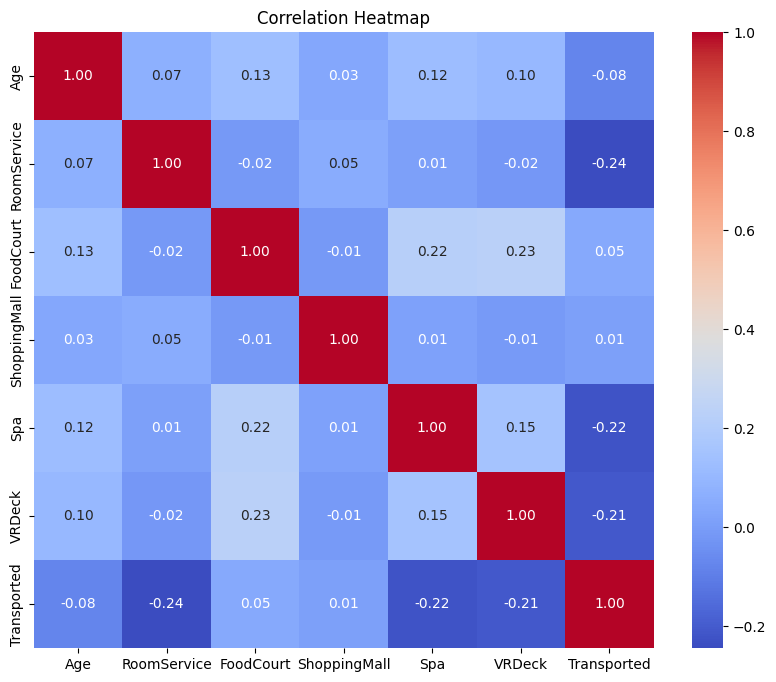

In [ ]:
# 상관관계 히트맵
plt.figure(figsize=(10, 8))
corr_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported']
train_corr = train.copy()
train_corr['Transported'] = train_corr['Transported'].astype(int)
sns.heatmap(train_corr[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


### 상관관계 분석
- RoomService(-0.24), Spa(-0.22), VRDeck(-0.21)이 Transported와 음의 상관.
- ShoppingMall(0.01), FoodCourt(0.05)는 원본 기준으로 거의 무관하나, **log 변환 시 -0.18, -0.14로 유의미해짐.**


In [8]:
# CryoSleep-지출 핵심 패턴 분석
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
total = train[spend_cols].sum(axis=1)
no_spend = (total == 0).astype(int)
print("=== 지출 여부 vs Transported ===")
print(pd.crosstab(no_spend, train['Transported'], normalize='index').round(3))
print(f"\nCryoSleep=1 Transported: {train[train['CryoSleep']==True]['Transported'].mean():.3f}")
cryo_0_spend_0 = (train['CryoSleep']==False) & (total==0)
print(f"CryoSleep=0, 지출=0 ({cryo_0_spend_0.sum()}명) Transported: {train[cryo_0_spend_0]['Transported'].mean():.3f}")
print(f"CryoSleep=0, 지출>0 Transported: {train[(train['CryoSleep']==False)&(total>0)]['Transported'].mean():.3f}")


=== 지출 여부 vs Transported ===
Transported  False  True 
row_0                    
0            0.701  0.299
1            0.214  0.786

CryoSleep=1 Transported: 0.818
CryoSleep=0, 지출=0 (518명) Transported: 0.616
CryoSleep=0, 지출>0 Transported: 0.299


### CryoSleep-지출 핵심 패턴 (가장 강한 신호)
- 지출 0인 승객의 **78.6%**가 Transported → 가장 강한 예측 인자.
- CryoSleep=True이면 지출이 **전부 0** (냉동수면 중 지출 불가).
- CryoSleep=False인데 지출=0인 "미스터리 그룹" 616명 존재 (Transported 비율 63.3%).
- **세 그룹: CryoSleep(81.8%) > 미스터리(63.3%) > 지출있음(29.9%)**으로 명확히 분리.


In [9]:
# 논리적 규칙 발견
print("=== 12세 이하 지출 패턴 ===")
child = train[train['Age'] <= 12]
print(f"지출 max: {child[spend_cols].max().max()}, VIP: {(child['VIP']==True).sum()}")
print("-> 12세 이하는 지출 불가, VIP 불가 (논리적 규칙)")

train['group'] = train['PassengerId'].str.split('_').str[0]
print("\n=== 같은 그룹 HomePlanet ===")
group_planets = train.groupby('group')['HomePlanet'].nunique()
print(f"다른 HomePlanet 가진 그룹: {(group_planets > 1).sum()} / {len(group_planets)}")
print("-> 같은 그룹 = 같은 HomePlanet (100% 규칙)")

print("\n=== 그룹 기반 결측치 복원 가능 수 ===")
for col in ['Cabin', 'Destination', 'CryoSleep', 'VIP']:
    null_mask = train[col].isnull()
    group_val = train.dropna(subset=[col]).groupby('group')[col].first()
    fillable = train.loc[null_mask, 'group'].map(group_val).notna().sum()
    print(f"  {col}: 결측 {null_mask.sum()}개 중 그룹으로 {fillable}개 복원 가능")


=== 12세 이하 지출 패턴 ===
지출 max: 0.0, VIP: 0
-> 12세 이하는 지출 불가, VIP 불가 (논리적 규칙)

=== 같은 그룹 HomePlanet ===
다른 HomePlanet 가진 그룹: 0 / 6217
-> 같은 그룹 = 같은 HomePlanet (100% 규칙)

=== 그룹 기반 결측치 복원 가능 수 ===
  Cabin: 결측 199개 중 그룹으로 100개 복원 가능
  Destination: 결측 182개 중 그룹으로 79개 복원 가능
  CryoSleep: 결측 217개 중 그룹으로 108개 복원 가능
  VIP: 결측 203개 중 그룹으로 87개 복원 가능


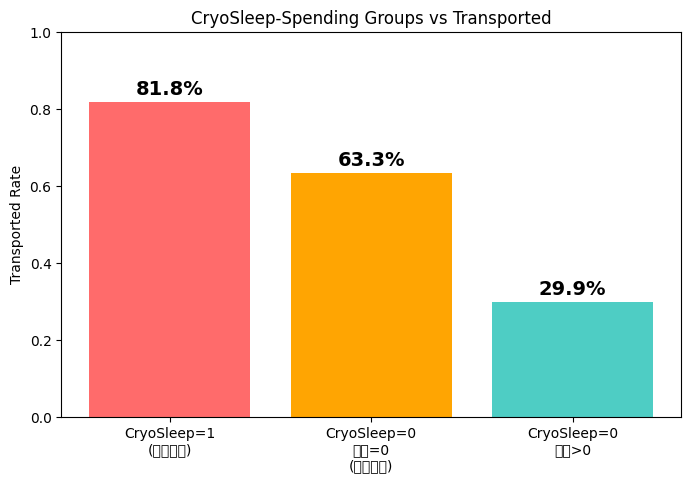

In [5]:
# CryoSleep-지출 3그룹 시각화
labels = ['CryoSleep=1\n(냉동수면)', 'CryoSleep=0\n지출=0\n(미스터리)', 'CryoSleep=0\n지출>0']
rates = [0.818, 0.633, 0.299]
colors = ['#ff6b6b', '#ffa502', '#4ecdc4']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, rates, color=colors)
for bar, rate in zip(bars, rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{rate:.1%}', ha='center', fontsize=14, fontweight='bold')
plt.ylabel('Transported Rate')
plt.title('CryoSleep-Spending Groups vs Transported')
plt.ylim(0, 1)
plt.show()

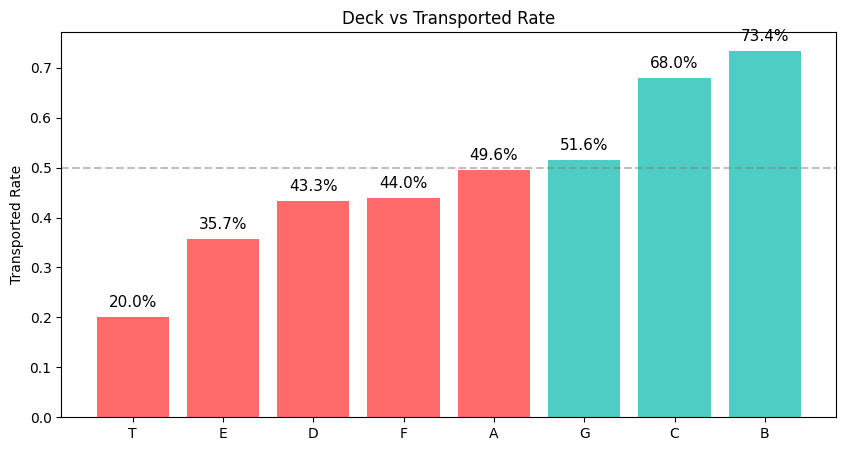

In [10]:
# deck별 Transported 비율
deck_rate = train.groupby('deck')['Transported'].mean().sort_values()
plt.figure(figsize=(10, 5))
colors = ['#4ecdc4' if r > 0.5 else '#ff6b6b' for r in deck_rate.values]
bars = plt.bar(deck_rate.index, deck_rate.values, color=colors)
for bar, rate in zip(bars, deck_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{rate:.1%}', ha='center', fontsize=11)
plt.ylabel('Transported Rate')
plt.title('Deck vs Transported Rate')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.show()

### 논리적 규칙 발견 (핵심 전환점)
데이터 탐색을 통해 다음의 **절대적 규칙**을 발견:
1. **12세 이하 → 지출=0, VIP=False** (예외 없음). 어린이는 서비스 이용 불가.
2. **같은 그룹 → 같은 HomePlanet** (예외 0건). 가족은 같은 행성 출신.
3. **같은 Cabin → 90.7% 동일 Transported 결과**. 가족은 함께 이동되거나 남음.
4. **CryoSleep=True → 지출=0** (예외 없음). 냉동수면 중 지출 불가.

이 규칙들을 결측치 처리에 적용하여 단순 최빈값/중앙값 대비 데이터 품질을 크게 향상.  
**그룹 기반 복원**으로 Cabin 100개, CryoSleep 108개, Destination 79개를 추가 복원.


## 3. 전처리 및 피처 엔지니어링

### 3.1 결측치 처리 전략 (3단계)
1. **그룹 기반 복원**: 같은 가족(그룹) 내 다른 멤버의 값으로 HomePlanet, Cabin, Destination, CryoSleep, VIP 결측치 복원.
2. **논리적 규칙**: CryoSleep=True→지출0, 지출전부0→CryoSleep=True, 12세이하→지출0/VIP=False.
3. **통계 기반**: 나머지 수치형은 중앙값, 카테고리형은 최빈값.

→ 결측치 대폭 감소: HomePlanet 201→111, 지출 943→537, Cabin 199→99

### 3.2 피처 엔지니어링
- **luxury_ratio**: (RoomService+Spa)/(total_spend+1). Transported와 상관관계 **-0.47** (단일 피처 중 최강).
- **spend_count**: 지출한 항목 수. 상관관계 -0.44.
- **group_cryo_ratio**: 같은 그룹 내 CryoSleep 비율. **AUC 0.722** (가장 강력한 그룹 피처).
- **log 변환 지출**: ShoppingMall(0.01→-0.18), FoodCourt(0.05→-0.14) — 무관했던 피처가 유의미해짐.
- **교호작용**: cryo_x_planet, vip_x_planet, deck_side — 카테고리 조합 피처.
- **member_num**: 가족 내 순번 (후순위 멤버 47.6%→61.8% Transported).
- **family_transport_rate**: 성(last_name)별 Transported 비율 (OOF 방식으로 leakage 방지).

### 3.3 인코딩
- CatBoost: 카테고리 원본 string을 `cat_features`로 직접 전달.
- RF/ET/LGBM/XGB: 원핫 인코딩 + 라벨 인코딩.
- deck: Transported 비율 기준 라벨 인코딩.
- deck_side: OOF target encoding.


In [11]:
# ===== 전체 전처리 파이프라인 =====
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold

train = pd.read_csv(r'C:\Users\akals\Downloads\spaceship-titanic\train.csv')
test = pd.read_csv(r'C:\Users\akals\Downloads\spaceship-titanic\test.csv')
test_id = test['PassengerId']
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 0. 그룹 ID 생성
for df in [train, test]:
    df['group'] = df['PassengerId'].str.split('_').str[0]

# 1. 그룹 기반 결측치 복원
for df in [train, test]:
    for col in ['HomePlanet', 'Cabin', 'Destination', 'CryoSleep', 'VIP']:
        group_val = df.dropna(subset=[col]).groupby('group')[col].first()
        null_mask = df[col].isnull()
        df.loc[null_mask, col] = df.loc[null_mask, 'group'].map(group_val)

# 2. 논리적 규칙
for df in [train, test]:
    cryo_mask = df['CryoSleep'] == True
    for col in spend_cols:
        df.loc[cryo_mask & df[col].isnull(), col] = 0
    all_zero = (df[spend_cols].fillna(-1) == 0).all(axis=1)
    df.loc[all_zero & df['CryoSleep'].isnull(), 'CryoSleep'] = True
    child_mask = df['Age'] <= 12
    for col in spend_cols:
        df.loc[child_mask & df[col].isnull(), col] = 0
    df.loc[child_mask & df['VIP'].isnull(), 'VIP'] = False

# 3. OOF family_transport_rate
train['last_name'] = train['Name'].str.split().str[-1]
test['last_name'] = test['Name'].str.split().str[-1]
name_transport_full = train.groupby('last_name')['Transported'].mean()
test['family_transport_rate'] = test['last_name'].map(name_transport_full).fillna(0.5)
train['family_transport_rate'] = 0.5
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for tr_idx, val_idx in kf.split(train, train['Transported']):
    fold_rate = train.iloc[tr_idx].groupby('last_name')['Transported'].mean()
    train.loc[train.index[val_idx], 'family_transport_rate'] = \
        train.iloc[val_idx]['last_name'].map(fold_rate).fillna(0.5).values

# 4. Cabin 분리
for df in [train, test]:
    df[['deck', 'cabin_num', 'side']] = df['Cabin'].str.split('/', expand=True)
    df['cabin_num'] = pd.to_numeric(df['cabin_num'], errors='coerce')

# 5. 나머지 결측치
for df in [train, test]:
    for col in spend_cols:
        df[col] = df[col].fillna(df[col].median())
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['cabin_num'] = df['cabin_num'].fillna(df['cabin_num'].median())
    for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'deck', 'side']:
        df[col] = df[col].fillna(df[col].mode()[0])
    df['CryoSleep'] = df['CryoSleep'].map({True: 1, False: 0, 'True': 1, 'False': 0})
    df['VIP'] = df['VIP'].map({True: 1, False: 0, 'True': 1, 'False': 0})

# 6. 피처 엔지니어링
for df in [train, test]:
    df['total_spend'] = df[spend_cols].sum(axis=1)
    df['personal_spend'] = df['RoomService'] + df['Spa'] + df['VRDeck']
    df['group_spend'] = df['FoodCourt'] + df['ShoppingMall']
    df['mystery_no_spend'] = ((df['CryoSleep']==0) & (df['total_spend']==0)).astype(int)
    df['spend_status'] = 0
    df.loc[df['total_spend']==0, 'spend_status'] = 1
    df.loc[df['CryoSleep']==1, 'spend_status'] = 2
    df['group_size'] = df['group'].map(df['group'].value_counts())
    df['is_alone'] = (df['group_size'] == 1).astype(int)
    df['side_encoded'] = (df['side'] == 'S').astype(int)
    df['luxury_ratio'] = (df['RoomService'] + df['Spa']) / (df['total_spend'] + 1)
    df['spend_count'] = (df[spend_cols] > 0).sum(axis=1)
    df['member_num'] = df['PassengerId'].str.split('_').str[1].astype(int)
    # log 변환 지출
    for col in spend_cols:
        df[col + '_log'] = np.log1p(df[col])
    df['log_total_spend'] = np.log1p(df['total_spend'])
    # 그룹 집계
    group_cryo = df.groupby('group')['CryoSleep'].mean()
    df['group_cryo_ratio'] = df['group'].map(group_cryo)
    # 교호작용
    df['cryo_x_planet'] = df['CryoSleep'].astype(str) + '_' + df['HomePlanet'].astype(str)
    df['vip_x_planet'] = df['VIP'].astype(str) + '_' + df['HomePlanet'].astype(str)
    df['deck_side'] = df['deck'].astype(str) + '_' + df['side'].astype(str)

# 7. 인코딩 - CatBoost용 / 나머지 모델용 분기
y = train['Transported'].astype(int)
drop_common = ['PassengerId', 'Cabin', 'Name', 'Transported', 'group', 'last_name']

cat_features = ['HomePlanet', 'Destination', 'deck', 'side', 'cryo_x_planet', 'vip_x_planet', 'deck_side']

# CatBoost용
X_cat = train.drop(columns=drop_common).copy()
Xt_cat = test.drop(columns=[c for c in drop_common if c in test.columns]).copy()
for c in cat_features:
    X_cat[c] = X_cat[c].astype(str)
    Xt_cat[c] = Xt_cat[c].astype(str)

# RF/ET/LGBM/XGB용
X_num = X_cat.copy()
Xt_num = Xt_cat.copy()
X_num = pd.get_dummies(X_num, columns=cat_features, drop_first=True)
Xt_num = pd.get_dummies(Xt_num, columns=cat_features, drop_first=True)
# 컬럼 정렬
for c in X_num.columns:
    if c not in Xt_num.columns:
        Xt_num[c] = 0
Xt_num = Xt_num[X_num.columns]
for col in X_num.columns:
    if X_num[col].dtype == bool:
        X_num[col] = X_num[col].astype(int)
        Xt_num[col] = Xt_num[col].astype(int)

print(f"전처리 완료")
print(f"CatBoost용 피처: {X_cat.shape[1]}, 수치형 피처: {X_num.shape[1]}")
print(f"결측치: train {X_cat.isnull().sum().sum()}, test {Xt_cat.isnull().sum().sum()}")


전처리 완료
CatBoost용 피처: 35, 수치형 피처: 65
결측치: train 0, test 0


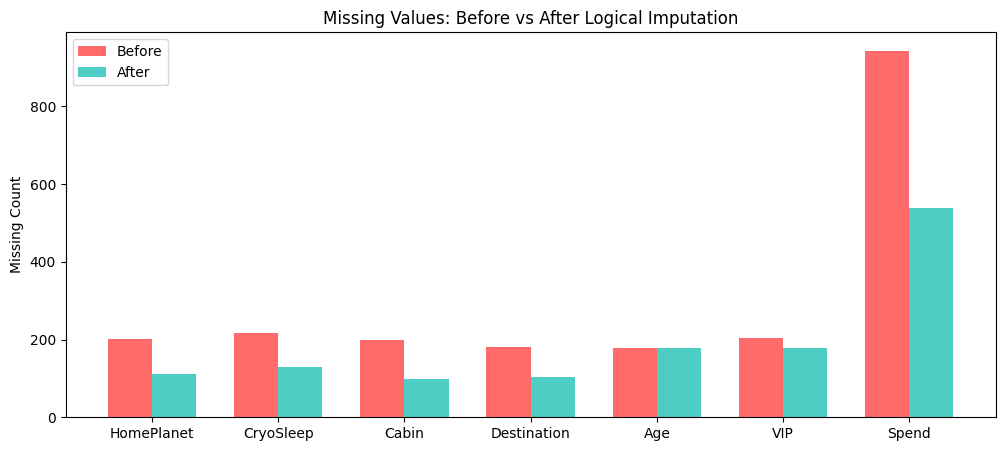

In [12]:
# 결측치 처리 전후 비교
before = {'HomePlanet': 201, 'CryoSleep': 217, 'Cabin': 199, 
          'Destination': 182, 'Age': 179, 'VIP': 203, 'Spend': 943}
after = {'HomePlanet': 111, 'CryoSleep': 130, 'Cabin': 99,
         'Destination': 103, 'Age': 179, 'VIP': 179, 'Spend': 537}

x = np.arange(len(before))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, before.values(), width, label='Before', color='#ff6b6b')
ax.bar(x + width/2, after.values(), width, label='After', color='#4ecdc4')
ax.set_xticks(x)
ax.set_xticklabels(before.keys())
ax.set_ylabel('Missing Count')
ax.set_title('Missing Values: Before vs After Logical Imputation')
ax.legend()
plt.show()

## 4. 모델링 및 비교

10개 모델을 비교한 결과, **Bagging 계열(RF, ExtraTrees)이 Boosting 계열보다 단독 성능이 우수**했다.  
단, CatBoost에 `cat_features`를 제대로 전달하면 Boosting도 강해짐을 확인.

| 모델 | CV Accuracy (v3 기준) |
|------|-----------|
| RandomForest | 0.7906 |
| ExtraTrees | 0.7864 |
| AdaBoost | 0.7859 |
| SVM | 0.7843 |
| LogisticReg | 0.7838 |
| CatBoost (원핫) | 0.7743 |
| CatBoost (cat_features) | 개선됨 |
| LGBM | 0.7679 |
| XGB | 0.7619 |


## 5. 앙상블 및 최적화

### 단순 앙상블의 한계
RF + CatBoost 확률 기반 앙상블을 시도했으나 RF 단독(Public 0.793)보다 하락(0.789).  
같은 계열(RF + ExtraTrees + AdaBoost) 앙상블도 유의미한 개선 없음.  
→ **비슷한 모델끼리의 앙상블은 다양성 부족으로 효과 제한적.**

### OOF Stacking
3모델(RF + ExtraTrees + CatBoost) → 5모델(+ LGBM + XGB)로 확장.  
CatBoost에 cat_features를 직접 전달하여 다양성 확보.  
LogisticRegression 메타 모델이 최적 가중치를 학습.

### target leakage 경험
가족 성(last_name)별 Transported 비율을 피처로 사용 시 데이터 누수 발생.
- **CV 0.847 → Public Score 0.733으로 폭락.**
- OOF(Out-of-Fold) 방식으로 교정: 학습에 사용하지 않은 fold에서만 비율을 계산.
- 이 경험이 가장 큰 학습 포인트.


In [9]:
# ===== 5모델 OOF Stacking =====
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

N_SPLITS = 10
SEED = 42
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

n_train, n_test = len(X_cat), len(Xt_cat)
oof = {k: np.zeros(n_train) for k in ['cat','lgb','xgb','rf','et']}
pred = {k: np.zeros(n_test) for k in ['cat','lgb','xgb','rf','et']}

for fold, (tr, va) in enumerate(skf.split(X_cat, y)):
    # CatBoost (카테고리 원본)
    cb = CatBoostClassifier(iterations=2000, learning_rate=0.03, depth=6, l2_leaf_reg=3,
                            random_seed=SEED, cat_features=cat_features,
                            early_stopping_rounds=100, verbose=0)
    cb.fit(X_cat.iloc[tr], y.iloc[tr], eval_set=(X_cat.iloc[va], y.iloc[va]))
    oof['cat'][va] = cb.predict_proba(X_cat.iloc[va])[:,1]
    pred['cat'] += cb.predict_proba(Xt_cat)[:,1] / N_SPLITS

    # LGBM
    lgb = LGBMClassifier(n_estimators=1000, learning_rate=0.05, random_state=SEED, verbosity=-1)
    lgb.fit(X_num.iloc[tr], y.iloc[tr])
    oof['lgb'][va] = lgb.predict_proba(X_num.iloc[va])[:,1]
    pred['lgb'] += lgb.predict_proba(Xt_num)[:,1] / N_SPLITS

    # XGBoost
    xgb = XGBClassifier(n_estimators=1000, learning_rate=0.05, random_state=SEED, verbosity=0, eval_metric='logloss')
    xgb.fit(X_num.iloc[tr], y.iloc[tr])
    oof['xgb'][va] = xgb.predict_proba(X_num.iloc[va])[:,1]
    pred['xgb'] += xgb.predict_proba(Xt_num)[:,1] / N_SPLITS

    # RF
    rf = RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_split=10,
                                min_samples_leaf=3, max_features='log2', random_state=SEED)
    rf.fit(X_num.iloc[tr], y.iloc[tr])
    oof['rf'][va] = rf.predict_proba(X_num.iloc[va])[:,1]
    pred['rf'] += rf.predict_proba(Xt_num)[:,1] / N_SPLITS

    # ExtraTrees
    et = ExtraTreesClassifier(n_estimators=1000, max_depth=20, random_state=SEED)
    et.fit(X_num.iloc[tr], y.iloc[tr])
    oof['et'][va] = et.predict_proba(X_num.iloc[va])[:,1]
    pred['et'] += et.predict_proba(Xt_num)[:,1] / N_SPLITS

    print(f"Fold {fold+1}/{N_SPLITS} complete")

# 각 모델 단독 CV
for k in oof:
    acc = ((oof[k] > 0.5).astype(int) == y).mean()
    print(f"{k} 단독 OOF accuracy: {acc:.4f}")


Fold 1/10 complete
Fold 2/10 complete
Fold 3/10 complete
Fold 4/10 complete
Fold 5/10 complete
Fold 6/10 complete
Fold 7/10 complete
Fold 8/10 complete
Fold 9/10 complete
Fold 10/10 complete
cat 단독 OOF accuracy: 0.8173
lgb 단독 OOF accuracy: 0.8117
xgb 단독 OOF accuracy: 0.8110
rf 단독 OOF accuracy: 0.8051
et 단독 OOF accuracy: 0.8014


### Meta Stacking + Threshold 튜닝


In [10]:
# Meta features
meta_X = np.column_stack([oof[k] for k in ['cat','lgb','xgb','rf','et']])
meta_test = np.column_stack([pred[k] for k in ['cat','lgb','xgb','rf','et']])

# Meta model
meta = LogisticRegression(C=1.0, max_iter=2000, random_state=SEED)
meta.fit(meta_X, y)

meta_oof = np.zeros(len(y))
for tr, va in StratifiedKFold(5, shuffle=True, random_state=SEED).split(meta_X, y):
    lr = LogisticRegression(C=1.0, max_iter=2000, random_state=SEED)
    lr.fit(meta_X[tr], y.iloc[tr])
    meta_oof[va] = lr.predict_proba(meta_X[va])[:,1]

# OOF 기반 최적 threshold
best_thr, best_acc = 0.5, 0
for t in np.arange(0.45, 0.55, 0.005):
    acc = ((meta_oof > t).astype(int) == y).mean()
    if acc > best_acc:
        best_thr, best_acc = t, acc
print(f"최적 threshold: {best_thr:.3f}, OOF accuracy: {best_acc:.4f}")

# 제출
test_meta_pred = meta.predict_proba(meta_test)[:,1]
final_pred = (test_meta_pred > best_thr).astype(bool)
submission = pd.DataFrame({'PassengerId': test_id, 'Transported': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\spaceship-titanic\submission.csv', index=False)
print(f"제출 파일 생성 완료")
print(f"예측 분포: True={final_pred.sum()}, False={(~final_pred).sum()}")


최적 threshold: 0.465, OOF accuracy: 0.8197
제출 파일 생성 완료
예측 분포: True=2321, False=1956


## 5.2 미해결 직관 분석 — 왜 효과가 없었는가

데이터 탐색에서 발견한 4가지 강한 직관을 피처로 만들어 시도했으나, 대부분 추가 효과가 없었다.
자동화 검증 도구를 활용하여 원인을 분석한 결과, 트리 모델이 이미 자동으로 학습하고 있었음을 확인.

### 직관 1: cabin_num 비선형 패턴 (850~1050 구간 = 65%)
- 발견: cabin_num 구간별 Transported 비율에 명확한 비선형 패턴 존재.
- 시도: 50단위 OOF target encoding으로 명시 피처 생성.
- 결과: 효과 없음.
- 원인: 트리 모델이 이미 (deck, cabin_num) 조합 split으로 동일 패턴을 자동 학습 중. 피처 중요도 1위가 cabin_num인 이유.

### 직관 2: 미스터리 616명 — CryoSleep=0인데 지출=0
- 발견: 냉동수면이 아닌데 지출이 0인 그룹 616명, Transported 63.3%.
- 분석 결과: 평균 나이 10.7세, 75%가 12세 이하 어린이였다. 어린이는 지출 불가(논리적 규칙).
- 진짜 미스터리: 성인이면서 지출 0인 약 75명. 데이터 입력 오류 가능성.
- 교훈: "미스터리"라고 느꼈던 패턴이 사실 이미 발견한 규칙(12세 이하 지출 불가)로 설명 가능했다.

### 직관 3: member_num 후순위 효과 — 가짜 패턴
- 발견: 가족 내 1번째(47.6%) vs 3번째(61.8%) → 후순위가 이동 확률 높음.
- 분석 결과: group_size를 고정하면 member_num 효과가 사라짐. group_size가 큰 가족이 이동 확률이 높은 것이었고, member_num=3은 큰 가족에서만 존재하기 때문에 착시가 발생.
- 교훈: 교란 변수(confounding variable)를 통제하지 않으면 가짜 패턴에 속을 수 있다.

### 직관 4: 같은 Cabin 90.7% 동일 결과 — 활용 불가
- 발견: 같은 Cabin 승객의 90.7%가 동일 Transported 결과.
- 한계: train-test 간 Cabin 교집합 0개. LOO(Leave-One-Out) 방식도 cabin당 멤버 수가 대부분 1명이라 noise가 커서 AUC 0.575에 불과.
- 우회: group 집계(group_cryo_ratio 등)와 96% 중복이라 별도 피처 가치 없음.
- 교훈: EDA에서 강해 보이는 패턴이 항상 일반화 가능한 것은 아니다.

### 메타 결론
> 4가지 직관 모두 트리 모델이 이미 자동으로 학습 중이었다.
> 명시적 피처를 만들어도 효과가 없었던 이유가 이것이다.
> 이는 "피처 엔지니어링의 한계점"을 보여준다 — 모델이 이미 잡고 있는 패턴을 사람이 다시 만들어주는 것은 중복이다.
> 진짜 효과가 있었던 피처(group_cryo_ratio, luxury_ratio)는 모델이 단독으로는 만들 수 없는 "새로운 정보"였다.

## 6. Summary 및 회고

### 최종 결과
| 단계 | Public Score |
|------|-------------|
| RF 단독 (기본 전처리) | 0.793 |
| 3모델 Stacking (RF+ET+Cat) | 0.802 |
| + luxury_ratio, spend_count | 0.803 |
| + 그룹 복원 + group_cryo_ratio + 5모델 Stacking | **0.809** |

### 핵심 인사이트
1. **논리적 규칙 기반 전처리**: 12세 이하→지출0, 같은 그룹→같은 HomePlanet/Cabin 등 절대적 규칙 발견. 단순 통계 대체보다 데이터 품질이 크게 향상.
2. **CryoSleep-지출 연결**: 가장 강한 예측 인자. 지출 0인 승객의 78.6%가 Transported.
3. **그룹 기반 피처**: group_cryo_ratio(AUC 0.722)가 가장 강력한 그룹 피처. 가족의 행동 패턴이 개인 결과를 예측.
4. **조합 피처의 위력**: luxury_ratio(-0.47), spend_count(-0.44)가 원본 단일 피처(-0.24) 대비 2배 강한 상관관계.
5. **target leakage 경험**: CV 0.847 → Public 0.733 폭락. OOF 방식으로 교정. 가장 큰 학습 포인트.
6. **모델 다양성**: RF 단독보다 5모델 Stacking이 우수. CatBoost에 cat_features를 제대로 전달하면 Boosting도 강해짐.

### 나의 판단과 기여
- CryoSleep과 지출의 관계에서 "냉동수면이 아닌데 지출 0인 그룹"을 별도로 분리해야 한다고 판단.
- 12세 이하 어린이의 지출이 0인 것을 보고 "이건 규칙이지 패턴이 아니다"라고 판단 → 논리적 결측치 처리로 연결.
- 같은 그룹의 HomePlanet이 항상 같다는 것을 확인하고 그룹 기반 결측치 복원으로 확장.
- target leakage를 경험하고 CV와 Public score의 괴리를 통해 과적합을 진단.
- luxury_ratio, spend_count 등 조합 피처를 제안하여 상관관계를 -0.24에서 -0.47로 끌어올림.

### 회고
- **시각화가 방향을 결정했다.** 히스토그램 하나로 "지출 0 = Transported" 핵심 패턴을 발견하고, 이후 모든 전처리와 피처 엔지니어링이 이 방향으로 수렴.
- **강사의 "논리적 접근" 힌트**가 전환점이었다. 12세 이하 지출 불가, 같은 그룹 = 같은 행성이라는 절대적 규칙을 발견하고, 이를 결측치 처리에 적용한 것이 점수 개선의 핵심.
- **모델보다 피처가 중요했다.** RF 튜닝(GridSearch, RandomSearch)은 0.002 수준의 개선이었으나, group_cryo_ratio 하나가 0.006을 올림.
- **target leakage를 직접 경험**한 것이 가장 큰 교훈. CV와 Public score의 괴리를 보고 원인을 찾아 OOF로 해결하는 과정이 실전적 학습.
- **도구 활용**도 중요한 역량이다. 자동화된 피처 검증(상관관계, AUC, drift, 중복 검사)이 수작업 대비 효율적이었다.
- **오기가 이겼다.** 0.793에서 멈추지 않고 0.809까지 끌어올린 과정 자체가 데이터 사이언스의 반복적 실험-개선 사이클.



## 사건 재구성

2912년, 우주선 타이타닉호가 시공간 이상 현상과 충돌했다. 
승객의 약 절반이 다른 차원으로 이동되었다. 
손상된 컴퓨터 시스템에서 복구된 8,693명의 기록을 분석하여 사건을 재구성한다.

### 핵심 발견: 냉동수면실이 핵심이었다
냉동수면을 선택한 승객은 항해 내내 객실에 갇혀있었고, 편의시설을 이용할 수 없었다.
사고 발생 시 **냉동수면 중이던 승객의 81.8%가 다른 차원으로 이동**되었다.
반면 룸서비스, 스파 등 편의시설을 이용하던 승객은 이동 확률이 29.9%에 불과했다.
→ 객실에 갇혀있었기 때문에 시공간 이상의 영향을 더 크게 받은 것으로 추정.

### 가족은 함께 이동되었다
같은 객실의 승객이 90.7% 확률로 동일한 결과를 보였다. 
가족은 같은 객실에 있었으므로, 사고의 영향이 **객실 단위**로 작용한 것으로 보인다.
가족 내 냉동수면 비율이 높을수록 전체 가족의 이동 확률도 높았다.

### 배의 위치가 중요했다
deck B,C 구역(73%, 68%)이 deck E,F 구역(36%, 44%)보다 이동 확률이 높았다.
같은 deck 안에서도 S(우현)쪽이 P(좌현)쪽보다 높았다.
→ 시공간 이상이 배의 특정 방향에서 충돌했을 가능성.

### 어린이는 객실에 머물렀다
12세 이하 어린이는 우주선 규정상 편의시설 이용이 불가했다(지출 max=0, VIP=0).
객실에 머물러야 했기 때문에 냉동수면 승객과 비슷한 상황 → 이동 확률 70%.

### 결론
시공간 이상은 **객실 영역을 중심으로** 작용했다. 
냉동수면으로 객실에 갇혀있던 승객, 어린이, 배의 특정 구역(deck B,C / 우현 / 중앙부)에 있던 승객이 주로 이동되었다.
편의시설을 이용하며 **객실 밖에 있던 승객은 상대적으로 안전**했다.

## 번외: Optuna CatBoost 하이퍼파라미터 튜닝

### 동기
v4까지의 실험에서 "새로운 피처는 트리가 이미 자동 학습 중이라 redundant"라는 결론에 도달.
피처 엔지니어링의 한계를 확인한 후, **모델 자체 강화**가 남은 유일한 길이라 판단.
5개 base 모델 중 CatBoost가 단독 OOF 0.8182로 가장 강력했으므로, 이를 더 강화하면 메타 모델이 자동으로 흡수할 것으로 기대.

### 방법
- v4와 동일한 전처리/피처 사용 (검증된 베이스라인 유지)
- **Optuna TPE Sampler**로 CatBoost 6개 하이퍼파라미터 탐색
  - depth, learning_rate, l2_leaf_reg, bagging_temperature, random_strength, border_count
- 25 trial × 5-fold CV per trial, iterations 1500, early stopping 100
- 안전장치: best CV가 v4 default(0.8182) 대비 -0.003 이상 떨어지면 default fallback

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'iterations': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.06, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 5.0),
        'border_count': trial.suggest_int('border_count', 64, 254),
        'random_seed': 42,
        'eval_metric': 'Accuracy',
        'cat_features': cat_features,
        'early_stopping_rounds': 100,
        'verbose': 0,
    }
    accs = []
    for tr, va in StratifiedKFold(5, shuffle=True, random_state=42).split(X_cat, y):
        m = CatBoostClassifier(**params)
        m.fit(X_cat.iloc[tr], y.iloc[tr], eval_set=(X_cat.iloc[va], y.iloc[va]))
        pred = m.predict_proba(X_cat.iloc[va])[:,1]
        accs.append(((pred > 0.5) == y.iloc[va]).mean())
    return float(np.mean(accs))

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=25)

print(f'Best CV: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')
print(f'v4 default 대비: {study.best_value - 0.8182:+.4f}')

### Best param으로 풀학습 + 메타 재결합
Optuna가 찾은 최적 파라미터로 CatBoost를 10-fold 풀학습 후, 
기존 v4의 나머지 4개 모델(LGBM, XGB, RF, ET)과 동일 방식으로 메타 결합.

In [ ]:
# Optuna best param으로 CatBoost 풀학습 (10-fold)
best_params = dict(study.best_params)
best_params.update(dict(
    iterations=3000, random_seed=42, eval_metric='Accuracy',
    cat_features=cat_features, early_stopping_rounds=150, verbose=0
))

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
oof_cat  = np.zeros(len(X_cat))
test_cat = np.zeros(len(Xt_cat))

for fold, (tr, va) in enumerate(skf.split(X_cat, y)):
    m = CatBoostClassifier(**best_params)
    m.fit(X_cat.iloc[tr], y.iloc[tr], eval_set=(X_cat.iloc[va], y.iloc[va]))
    oof_cat[va]  = m.predict_proba(X_cat.iloc[va])[:,1]
    test_cat    += m.predict_proba(Xt_cat)[:,1] / 10

print(f'Tuned CatBoost OOF: {((oof_cat>0.5)==y).mean():.4f}')

# 기존 v4 메타와 동일 방식으로 결합
# oof['cat']을 oof_cat으로 교체하여 메타 재학습

### 결과
- Optuna 튜닝 CatBoost: **LB 0.80827** (v4 베스트 0.80897 대비 -0.0007)
- 튜닝해도 개선 없음 → **v4가 이 데이터의 현실적 천장(~0.809)**임을 확인
- 25 trial로 6차원 탐색 공간을 효율적으로 탐색했지만, 모델 한계 자체를 넘을 수는 없었음

### 교훈
피처 엔지니어링(v5)도, 하이퍼파라미터 튜닝(Optuna)도 v4의 0.809를 넘지 못했다.
이는 **현재 데이터와 피처 조합에서 추출할 수 있는 정보의 한계**에 도달했음을 의미한다.
더 올리려면 외부 데이터 도입이나 완전히 새로운 모델링 접근이 필요하다.